# Overview
Ten notebook jest przeznaczony do analizy algorytmów redukcji wymiarowości na zbiorze **iris**

https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html

Badamy następujace algorytmy:

- Linear Discriminant Analysis (LDA) (nadzorowane)

- Principal Component Analysis (PCA)

- Kernel PCA

- IsoMap

- UMap

- AutoEncoder

- t-SNE -> głownie do wizualizacji 



Dla kaźdego algorytmu został napisany nastepujący pipeline;
Wybieramy skalowanie danych uźywamy 4 rodzaje:

        StandardScaler()

        RobustScaler()

        MinMaxScaler()

        brak skalowania




0. Dzielimy zbiór na testowy i treningowym 
    X_train, y_train, X_test, y_test = train_test_split(X, 0.8)

1. robimy osobno transform na testowym i treningowym tzn np.:
        X_train_pca = pca.fit_tranform(X_train)
        X_test_pca = pca.transform(X)

2. Będziemy sprawdzać jakość prodykcji za pomocą regresji logistycznej 

dla róźnej liczby zredukowanych wymiarów

3. sprawdzać jakość utworzonych klastrów po redukcji za pomocą metryk zewnętrznych jak i wewnętrznych 


4. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.datasets import load_iris
from utils.scores import Dataset, DatasetEvaluator
from utils.plots import plot_2d_projection, plot_3d_interactive, plot_2d_projection_comparison

## Loading Datasets

In [3]:
iris = load_iris()
X = iris.data
y = iris.target


evaluators = {'StandardScaler': DatasetEvaluator( Dataset(X, y, 'Iris')),
               'MinMaxScaler': DatasetEvaluator( Dataset(X, y, 'Iris')), 
               'RobustScaler': DatasetEvaluator( Dataset(X, y, 'Iris')), 
               'original': DatasetEvaluator( Dataset(X, y, 'Iris'))}

In [4]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

for name, evaluator in evaluators.items():
    if name != 'original':
        scaler = None
        if name == 'StandardScaler':
            scaler = StandardScaler()
        elif name == 'MinMaxScaler':
            scaler = MinMaxScaler()
        elif name == 'RobustScaler':
            scaler = RobustScaler()
        evaluator.scale(scaler)
        print(evaluator.X_train[:5])



Scaling with StandardScaler...
[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]
 [ 1.08589829  0.08570939  0.38585821  0.28921757]
 [-1.23014297  0.75647855 -1.2187007  -1.31260282]
 [-1.7177306   0.30929911 -1.39061772 -1.31260282]]
Scaling with MinMaxScaler...
[[0.08823529 0.66666667 0.         0.04166667]
 [0.41176471 1.         0.0877193  0.125     ]
 [0.70588235 0.45833333 0.59649123 0.54166667]
 [0.14705882 0.58333333 0.10526316 0.04166667]
 [0.02941176 0.5        0.05263158 0.04166667]]
Scaling with RobustScaler...
[[-0.88461538  1.         -0.90277778 -0.73333333]
 [-0.03846154  2.33333333 -0.76388889 -0.6       ]
 [ 0.73076923  0.16666667  0.04166667  0.06666667]
 [-0.73076923  0.66666667 -0.73611111 -0.73333333]
 [-1.03846154  0.33333333 -0.81944444 -0.73333333]]


In [11]:
reductions = {
    'StandardScaler': {},
    'MinMaxScaler': {},
    'RobustScaler': {},
    'original': {}
}

kmeans_results = {}
logistic_regression_results = {}

## LDA

In [6]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

[[-1.47393679  1.20365799 -1.56253475 -1.31260282]
 [-0.13307079  2.99237573 -1.27600637 -1.04563275]]
[[0.08823529 0.66666667 0.         0.04166667]
 [0.41176471 1.         0.0877193  0.125     ]]
[[-0.88461538  1.         -0.90277778 -0.73333333]
 [-0.03846154  2.33333333 -0.76388889 -0.6       ]]
[[4.6 3.6 1.  0.2]
 [5.7 4.4 1.5 0.4]]


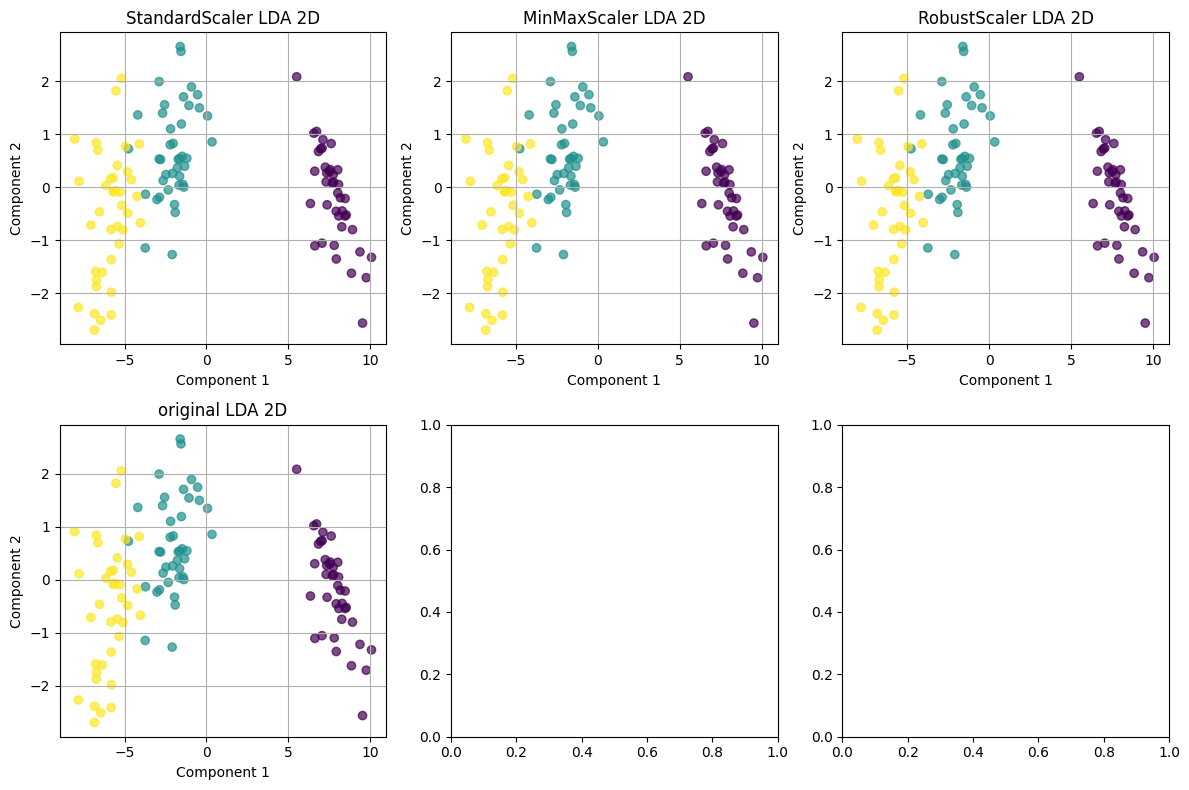

In [14]:

for name, evaluator in evaluators.items():
    LDA_model_2d = LinearDiscriminantAnalysis(n_components=2)
    print(evaluator.X_train[:2])
    X_train_2d = LDA_model_2d.fit_transform(evaluator.X_train, evaluator.y_train)
    X_test_2d = LDA_model_2d.transform(evaluator.X_test)
    reductions[name]['LDA_2d'] = (X_train_2d, X_test_2d)

plot_2d_projection_comparison([(reductions[name]['LDA_2d'][0], f"{name} LDA 2D") for name in reductions], y=evaluator.y_train)


In [16]:
evaluator = evaluators['StandardScaler']
kmeans_results['LDA_2d'] = evaluator._evaluate_reduction_with_kmeans(*reductions['StandardScaler']['LDA_2d'])
logistic_regression_results['LDA_2d'] = evaluator._evaluate_reduction_with_logistic_regression(*reductions['StandardScaler']['LDA_2d'])

AttributeError: 'DatasetEvaluator' object has no attribute '_evaluate_reduction_with_logistic_regression'

# PCA

In [32]:
from utils.pca import my_pca
import sys
sys.modules['utils.pca'].pd = pd

model_pca = my_pca(n_components=2)
X_pca, df_pca = model_pca.fit(X_scaled)

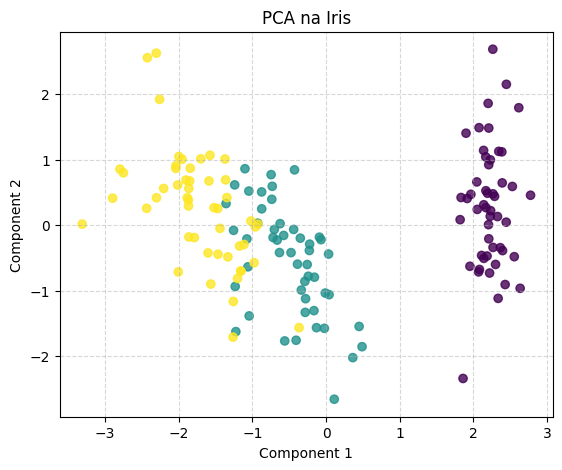

In [33]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(df_pca['PC_1'], df_pca['PC_2'], c=y, alpha=0.8)
plt.title("PCA na Iris")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle='--', alpha=0.5)

In [34]:
trust_pca = trustworthiness(X_scaled, X_pca, n_neighbors=5)
print(f"Trustworthiness dla PCA: {trust_pca:.4f}")

Trustworthiness dla PCA: 0.9742


In [41]:
from sklearn.metrics import normalized_mutual_info_score, silhouette_score, calinski_harabasz_score
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=10,
    random_state=1,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

nmi_pca = normalized_mutual_info_score(
    y,
    clusters
)

sil_pca = silhouette_score(
    X_pca,
    clusters
)

cal_har = calinski_harabasz_score(
    X_pca,
    clusters
)
print(f"NMI dla PCA: {nmi_pca:.4f}")
print(f"Silhouette dla PCA: {sil_pca:.4f}")
print(f"Calinski-Harabasz dla PCA: {cal_har:.4f}")

NMI dla PCA: 0.5468
Silhouette dla PCA: 0.4408
Calinski-Harabasz dla PCA: 298.0534


## Kernel PCA

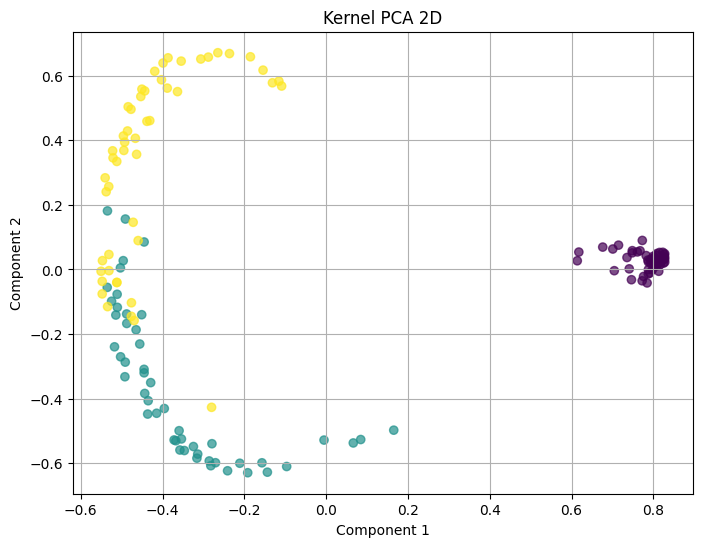

In [ ]:
from sklearn.decomposition import PCA, KernelPCA

PCA_2d = KernelPCA(n_components=2, kernel='rbf')
X_pca_2d = PCA_2d.fit_transform(iris_dataset.X)
iris_dataset.plot_projection(X_pca_2d, title="Kernel PCA 2D")

In [ ]:
from sklearn.manifold import trustworthiness

trustworthiness(X, X_pca_2d, n_neighbors=5)

np.float64(0.9265070422535211)

## TSNE

In [8]:
from sklearn.manifold import TSNE
model_tsne = TSNE(n_components=2, perplexity=30)
X_tsne = model_tsne.fit_transform(X)
model_tsne.transform(X)


AttributeError: 'TSNE' object has no attribute 'transform'

In [ ]:
df_tsne = pd.DataFrame(
    X_tsne,
    columns=['TSNE_1', 'TSNE_2']
)

In [ ]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_tsne['TSNE_1'], df_tsne['TSNE_2'], c=y, alpha=0.8)
plt.title("t-SNE na Iris")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
trust_tsne = trustworthiness(X_scaled, X_tsne, n_neighbors=5)
print(f"Trustworthiness dla t-SNE: {trust_tsne:.4f}")

## Autoencoder

In [ ]:
from utils.autoencoder import autoencoder

model_ae = autoencoder(input_dim=X_scaled.shape[1], latent_dim=2)

model_ae.fit(X_scaled, epochs=200)
X_ae = model_ae.transform(X_scaled)

ImportError: cannot import name 'autoencoder' from 'utils.autoencoder' (/Users/wiktor/dim_red/Dimensionality-reduction-project/utils/autoencoder.py)

In [ ]:
df_ae = pd.DataFrame(X_ae, columns=["AE_1", "AE_2"])

In [ ]:
plt.scatter(df_ae["AE_1"], df_ae["AE_2"], c=y)
plt.title("Autoencoder na Iris")
plt.show()

In [ ]:
trust_ae = trustworthiness(X_scaled, X_ae, n_neighbors=5)
print(f"Trustworthiness dla Autoencodera: {trust_ae:.4f}")

# Isomap i UMAP

In [ ]:
def plot_embedding(embedding, labels, title="", ax=None):

    """Rysuje embedding 2D, kolorując punkty wg etykiet."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(title)
    ax.grid(True, which="major", linewidth=0.5, color="gray", alpha=0.5)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


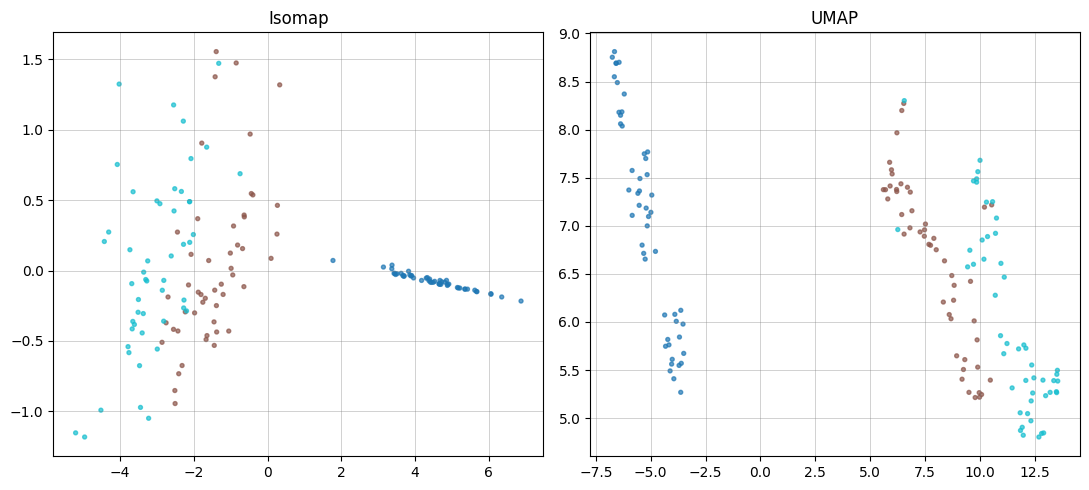

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from utils.isomap_umap import isomap, umap_reduce

X, y = load_iris(return_X_y=True)


emb_iso = isomap(X)
emb_umap = umap_reduce(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_embedding(emb_iso, y, "Isomap", ax=axes[0])
plot_embedding(emb_umap, y, "UMAP", ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
X, y = load_iris(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)

neighbor_values = [5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]

iso_scores, umap_scores = [], []
for k in neighbor_values:
    emb_iso = isomap(X_scaled, n_neighbors=k, scale=False)
    emb_umap = umap_reduce(X_scaled, n_neighbors=k, scale=False)
    iso_scores.append(trustworthiness(X_scaled, emb_iso))
    umap_scores.append(trustworthiness(X_scaled, emb_umap))


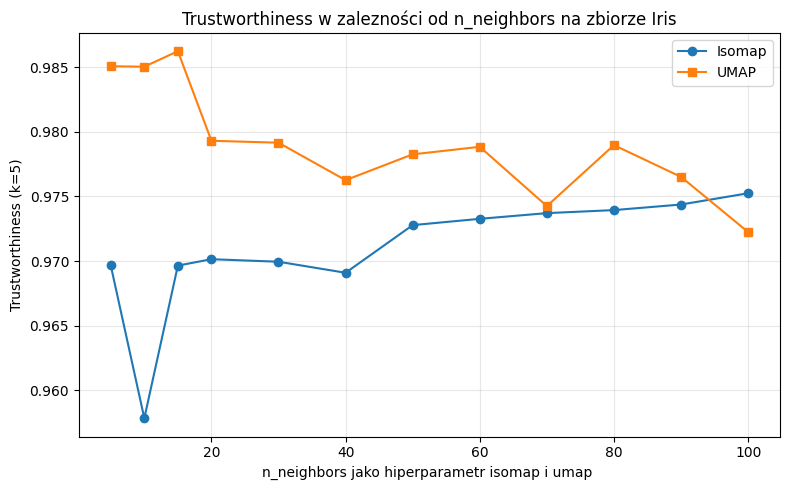

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(neighbor_values, iso_scores, "o-", label="Isomap")
plt.plot(neighbor_values, umap_scores, "s-", label="UMAP")
plt.xlabel("n_neighbors jako hiperparametr isomap i umap ")
plt.ylabel(f"Trustworthiness")
plt.title("Trustworthiness w zalezności od n_neighbors na zbiorze Iris")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    normalized_mutual_info_score,
    silhouette_score,
    calinski_harabasz_score,
)
from utils.isomap_umap import isomap, umap_reduce

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

X, y = load_iris(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)
n_clusters = len(np.unique(y))

neighbor_values = [5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100]

metrics = ["NMI", "Silhouette", "Calinski-Harabasz"]
results = {m: {"isomap": [], "umap": []} for m in metrics}


In [ ]:
for k in neighbor_values:
    for name, fn in [("isomap", isomap), ("umap", umap_reduce)]:
        emb = fn(X_scaled, n_neighbors=k, scale=False)
        km = KMeans(n_clusters=n_clusters, random_state=1, n_init=10).fit_predict(emb)

        results["NMI"][name].append(normalized_mutual_info_score(y, km))
        results["Silhouette"][name].append(silhouette_score(emb, y))
        results["Calinski-Harabasz"][name].append(calinski_harabasz_score(emb, y))



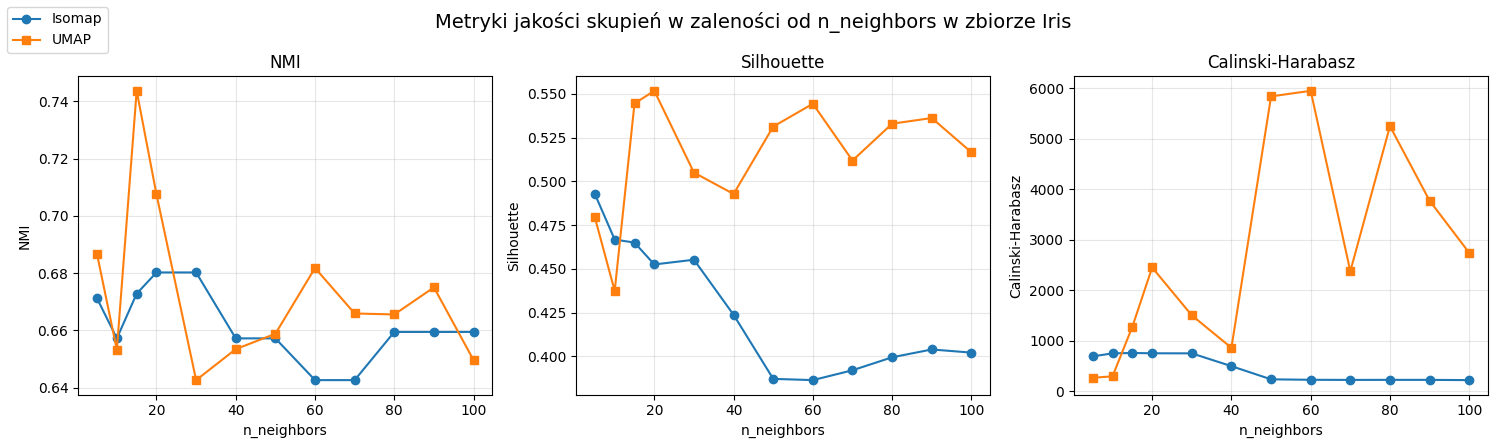

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, metrics):
    ax.plot(neighbor_values, results[metric]["isomap"], "o-", label="Isomap")
    ax.plot(neighbor_values, results[metric]["umap"], "s-", label="UMAP")
    ax.set_title(metric)
    ax.set_xlabel("n_neighbors")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)


handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=1)

fig.suptitle("Metryki jakości skupień w zaleności od n_neighbors w zbiorze Iris", fontsize=14)
fig.tight_layout()
plt.show()